# 03 · FinX baselines (Naive, Moving Average, ARIMA, Naive Bayes)

**Target:** `target_next_ret` = next-day S&P 500 return
**Validation:** walk-forward, expanding window (same folds as every other FinX model)

| Fold | Train | Test |
|---|---|---|
| 1 | 2021-01-04 to 2023 | 2024 |
| 2 | 2021-01-04 to 2024 | 2025 |
| 3 | 2021-01-04 to 2025 | 2026 to 21 Sep |

**Input:** `data/gold/master.csv` only (the frozen master, read through `load_master()`); the real ^GSPC close from `data/raw/` is used just for the level plot and ADF test. Nothing is downloaded here, so the numbers cannot drift. Folds, predictions and scoring come from the shared code in `src/` (`finx_common.py`, `baselines.py`), the same code the smoke test and every other model use.

**Naive Bayes** is a midterm model kept for reference. It is not one of the five FinX models (SARIMA, XGBoost, DNN, LSTM, Chronos-Bolt).

**Outputs** (in `outputs/baselines/`): `table6_results.csv`, `table6_by_fold.csv`, `arima_orders.csv`, `stationarity.csv`, and all figures as PNG.

## 1. Setup

In [1]:
import itertools
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "src")]
import config as C
import baselines as B                # shared Naive / MA(5) / ARIMA
from finx_common import FOLDS, fold_split, load_master

warnings.filterwarnings("ignore")
%matplotlib inline
pd.set_option("display.width", 140)

In [2]:
# ---- Configuration (all values come from config.py) ----
TEST_YEARS = [int(f[0]) for f in FOLDS]    # 2024, 2025, 2026
MA_WINDOW = C.WINDOW
NB_LAGS = C.WINDOW    # Naive Bayes uses the last 5 daily returns as features
OUT = C.OUT_DIR / "baselines"
os.makedirs(OUT, exist_ok=True)

## 2. Load the frozen master and take the index return

In [3]:
master = load_master()                       # data/gold/master.csv: 1 row per trading day, 58 inputs + target
ret = master["ret_index"]                    # known at the close of day t
# Index level for the plot and the ADF test only (not a model input): the real ^GSPC close from data/raw/.
raw = pd.read_csv(C.RAW_PATH, header=[0, 1], index_col=0, parse_dates=True)
level = raw["Close"][C.INDEX_TICKER].dropna().loc[master.index.min():master.index.max()]
print(f"{len(master)} trading days: {master.index.min().date()} to {master.index.max().date()}; "
      f"{master.shape[1]} columns")
ret.describe()

1435 trading days: 2021-01-04 to 2026-09-21; 59 columns


count    1435.000000
mean        0.000560
std         0.010424
min        -0.059750
25%        -0.004578
50%         0.000769
75%         0.006210
max         0.095154
Name: ret_index, dtype: float64

### Exploratory view: index level vs daily return
Shaded regions are the three walk-forward test years.

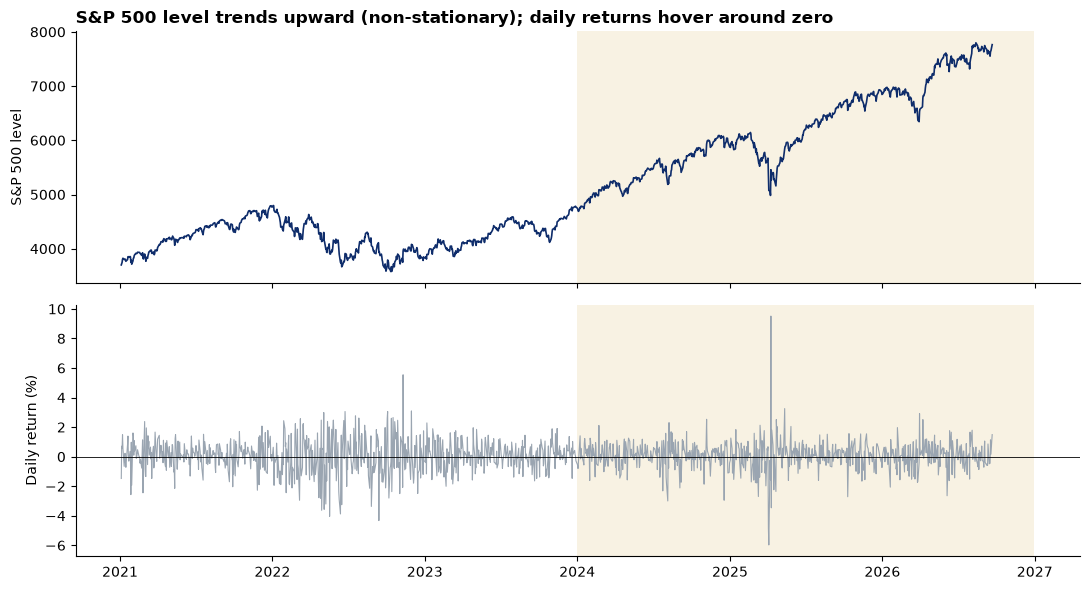

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(level.index, level, color="#0f2d6b", lw=1.2)
axes[0].set_ylabel("S&P 500 level")
axes[0].set_title("S&P 500 level trends upward (non-stationary); daily returns hover around zero",
                  fontsize=12, fontweight="bold", loc="left")
axes[1].plot(ret.index, ret * 100, color="#9aa5b1", lw=0.8)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_ylabel("Daily return (%)")
for ax in axes:
    for yr in TEST_YEARS:
        ax.axvspan(pd.Timestamp(f"{yr}-01-01"), pd.Timestamp(f"{yr}-12-31"),
                   color="#f2e6c9", alpha=0.5, lw=0)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{OUT}/fig_level_vs_return.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Stationarity check (ADF)
Price should fail the ADF test (p > 0.05); returns should pass (p < 0.05). This justifies modelling returns with d = 0.

In [5]:
stat = pd.DataFrame([
    {"series": "S&P 500 level", "ADF stat": adfuller(level)[0], "p-value": adfuller(level)[1]},
    {"series": "Daily return", "ADF stat": adfuller(ret)[0], "p-value": adfuller(ret)[1]},
]).round(4)
stat.to_csv(f"{OUT}/stationarity.csv", index=False)
stat

,series,ADF stat,p-value
0,S&P 500 level,0.4048,0.9817
1,Daily return,-23.5138,0.0000


## 4. Models

In [6]:
# Naive, MA(5) and ARIMA come from src/baselines.py (shared with the smoke test).
# Row t holds the forecast of the NEXT day's return, made with data up to day t.
def naive_bayes_direction(master, train_idx, test_idx):
    """Gaussian Naive Bayes: returns of days t-4..t -> will the next day be up (1) or down (0)?"""
    X = pd.concat({f"lag{k}": master["ret_index"].shift(k) for k in range(NB_LAGS)}, axis=1)
    y = (master[C.TARGET] > 0).astype(int)
    clf = GaussianNB().fit(X.loc[train_idx].dropna(), y.loc[X.loc[train_idx].dropna().index])
    Xte = X.loc[test_idx]
    return pd.Series(clf.predict(Xte), index=test_idx)

## 5. Metrics

In [7]:
def direction_pct(pred_sign, actual):
    mask = actual != 0
    return 100 * (np.sign(pred_sign[mask]) == np.sign(actual[mask])).mean()


def score(actual, pred, naive_rmse=None, has_direction=True):
    err = actual - pred
    rmse = np.sqrt((err ** 2).mean())
    out = {"RMSE": rmse, "MAE": err.abs().mean(),
           "Direction %": direction_pct(pred, actual) if has_direction else np.nan}
    out["Skill vs naive"] = 1 - rmse / naive_rmse if naive_rmse else 0.0
    return out

## 6. Walk-forward evaluation
The ARIMA order search runs 16 fits per fold, so this cell can take a minute or two.

In [8]:
rows, orders, preds_all = [], [], []
for fold in FOLDS:
    yr = int(fold[0])
    train, test = fold_split(master, fold)
    test_idx = test.index
    print(f"Fold: train {train.index.min().year}-{train.index.max().year} -> test {yr} ({len(test_idx)} days)")
    actual = test[C.TARGET]

    p_naive = B.naive_predict(None, master, test_idx)
    p_ma = B.ma_predict(None, master, test_idx)
    m = B.arima_fit(train)
    p_arima = B.arima_predict(m, master, test_idx)
    lb_p = float(acorr_ljungbox(m["fit"].resid, lags=[10], return_df=True)["lb_pvalue"].iloc[0])
    p_nb = naive_bayes_direction(master, train.index, test_idx)
    orders.append({"test_year": yr, "train_days": len(train), "order": f"ARIMA{m['order']}",
                   "train_AIC": round(m["fit"].aic, 1), "LjungBox_p_lag10": round(lb_p, 3)})

    preds_all.append(pd.DataFrame({"actual": actual, "Naive": p_naive,
                                   "MA(5)": p_ma, "ARIMA": p_arima,
                                   "NB_up": p_nb.reindex(test_idx)}))

    naive_rmse = np.sqrt((actual ** 2).mean())
    for name, p in [("Naive (return = 0)", p_naive), ("Moving average (5-day)", p_ma),
                    ("ARIMA", p_arima)]:
        rows.append({"test_year": yr, "Model": name,
                     **score(actual, p, None if name.startswith("Naive") else naive_rmse,
                             has_direction=not name.startswith("Naive"))})
    nb_sign = p_nb.reindex(test_idx).map({1: 1, 0: -1})
    rows.append({"test_year": yr, "Model": "Naive Bayes (up/down)", "RMSE": np.nan,
                 "MAE": np.nan, "Direction %": direction_pct(nb_sign, actual),
                 "Skill vs naive": np.nan})
    rows.append({"test_year": yr, "Model": "Always 'up' (direction benchmark)",
                 "RMSE": np.nan, "MAE": np.nan,
                 "Direction %": direction_pct(pd.Series(1, index=test_idx), actual),
                 "Skill vs naive": np.nan})

by_fold = pd.DataFrame(rows)
by_fold.to_csv(f"{OUT}/table6_by_fold.csv", index=False)
arima_orders = pd.DataFrame(orders)
arima_orders.to_csv(f"{OUT}/arima_orders.csv", index=False)

Fold: train 2021-2023 -> test 2024 (252 days)


Fold: train 2021-2024 -> test 2025 (250 days)


Fold: train 2021-2025 -> test 2026 (180 days)


### ARIMA order chosen per fold
Ljung-Box p > 0.05 means no significant autocorrelation left in the residuals.

In [9]:
arima_orders

,test_year,train_days,order,train_AIC,LjungBox_p_lag10
0,2024,753,"ARIMA(0, 0, 0)",-4639.7,0.574
1,2025,1005,"ARIMA(0, 0, 0)",-6323.7,0.377
2,2026,1255,"ARIMA(0, 0, 3)",-7828.6,0.942


### Results per test year

In [10]:
by_fold.round(4)

,test_year,Model,RMSE,MAE,Direction %,Skill vs naive
0,2024,Naive (return = 0),0.0080,0.0059,NaN,0.0000
1,2024,Moving average (5-day),0.0089,0.0067,52.3810,-0.1125
2,2024,ARIMA,0.0080,0.0059,56.7460,0.0040
3,2024,Naive Bayes (up/down),NaN,NaN,53.9683,NaN
4,2024,Always 'up' (direction benchmark),NaN,NaN,56.7460,NaN
5,2025,Naive (return = 0),0.0118,0.0073,NaN,0.0000
6,2025,Moving average (5-day),0.0133,0.0081,50.4000,-0.1227
7,2025,ARIMA,0.0118,0.0073,58.0000,0.0016
8,2025,Naive Bayes (up/down),NaN,NaN,51.6000,NaN
9,2025,Always 'up' (direction benchmark),NaN,NaN,58.0000,NaN


## 7. Table 6: overall results (all test days pooled)
RMSE and MAE are shown in percentage points of daily return.

In [11]:
P = pd.concat(preds_all)
a = P["actual"]
naive_rmse = np.sqrt((a ** 2).mean())
overall = [
    {"Model": "Naive (return = 0)", **score(a, P["Naive"], None, has_direction=False)},
    {"Model": "Moving average (5-day)", **score(a, P["MA(5)"], naive_rmse)},
    {"Model": "ARIMA", **score(a, P["ARIMA"], naive_rmse)},
    {"Model": "Naive Bayes (up/down)", "RMSE": np.nan, "MAE": np.nan,
     "Direction %": direction_pct(P["NB_up"].map({1: 1, 0: -1}), a), "Skill vs naive": np.nan},
    {"Model": "Always 'up' (direction benchmark)", "RMSE": np.nan, "MAE": np.nan,
     "Direction %": direction_pct(pd.Series(1, index=a.index), a), "Skill vs naive": np.nan},
]
table6 = pd.DataFrame(overall)
for c in ["RMSE", "MAE"]:
    table6[c] = table6[c] * 100
table6 = table6.rename(columns={"RMSE": "RMSE (%)", "MAE": "MAE (%)"}).round(3)
table6.to_csv(f"{OUT}/table6_results.csv", index=False)
table6

,Model,RMSE (%),MAE (%),Direction %,Skill vs naive
0,Naive (return = 0),0.966,0.658,NaN,0.000
1,Moving average (5-day),1.073,0.729,50.147,-0.110
2,ARIMA,0.964,0.655,54.106,0.002
3,Naive Bayes (up/down),NaN,NaN,51.173,NaN
4,Always 'up' (direction benchmark),NaN,NaN,56.012,NaN


## 8. Visualisations

### Figure 6: ARIMA vs actual returns (2025 test year)

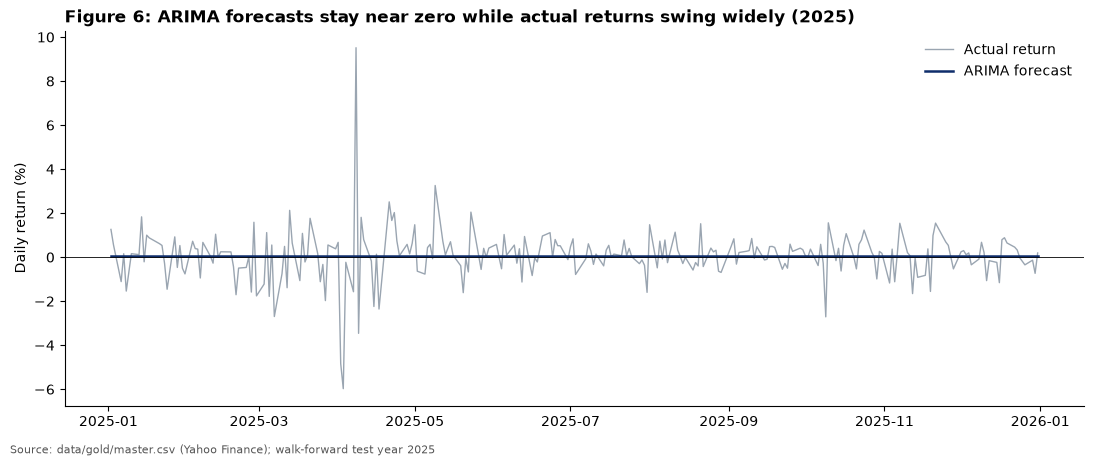

In [12]:
FIG6_YEAR = 2025
p25 = P[P.index.year == FIG6_YEAR]
if len(p25):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(p25.index, p25["actual"] * 100, color="#9aa5b1", lw=1, label="Actual return")
    ax.plot(p25.index, p25["ARIMA"] * 100, color="#0f2d6b", lw=1.8, label="ARIMA forecast")
    ax.axhline(0, color="black", lw=0.6)
    ax.set_title(f"Figure 6: ARIMA forecasts stay near zero while actual returns swing widely ({FIG6_YEAR})",
                 fontsize=12, fontweight="bold", loc="left")
    ax.set_ylabel("Daily return (%)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, loc="upper right")
    fig.text(0.01, -0.02, f"Source: data/gold/master.csv (Yahoo Finance); walk-forward test year {FIG6_YEAR}",
             fontsize=8, color="#555")
    fig.tight_layout()
    fig.savefig(f"{OUT}/fig6_arima_vs_actual_{FIG6_YEAR}.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print(f"No {FIG6_YEAR} data in the file.")

### Direction accuracy vs coin flip (all test years pooled)

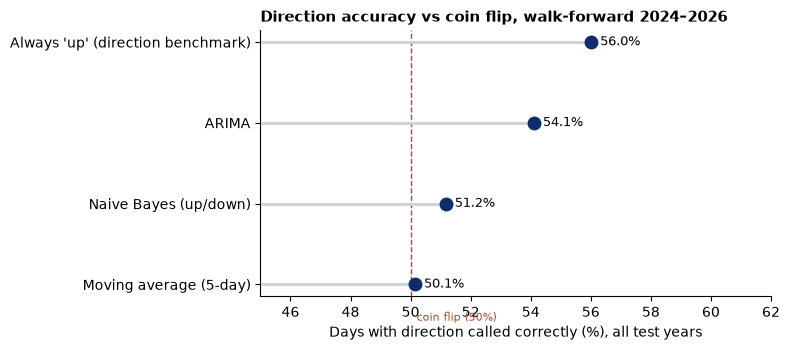

In [13]:
d = table6.dropna(subset=["Direction %"]).sort_values("Direction %")
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.axvline(50, color="#b24a28", ls="--", lw=1)
ax.text(50.2, -0.45, "coin flip (50%)", color="#b24a28", fontsize=8)
ax.hlines(range(len(d)), 45, d["Direction %"], color="#c9d2d9", lw=2)
ax.plot(d["Direction %"], range(len(d)), "o", color="#0f2d6b", ms=9)
for i, v in enumerate(d["Direction %"]):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_yticks(range(len(d)), d["Model"])
ax.set_xlim(45, max(62, d["Direction %"].max() + 3))
ax.set_xlabel("Days with direction called correctly (%), all test years")
ax.set_title(f"Direction accuracy vs coin flip, walk-forward {TEST_YEARS[0]}–{TEST_YEARS[-1]}",
             fontsize=11, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{OUT}/fig_direction_accuracy.png", dpi=200, bbox_inches="tight")
plt.show()

### Direction accuracy by test year
Shows whether any model's edge holds up across years or is driven by one fold.

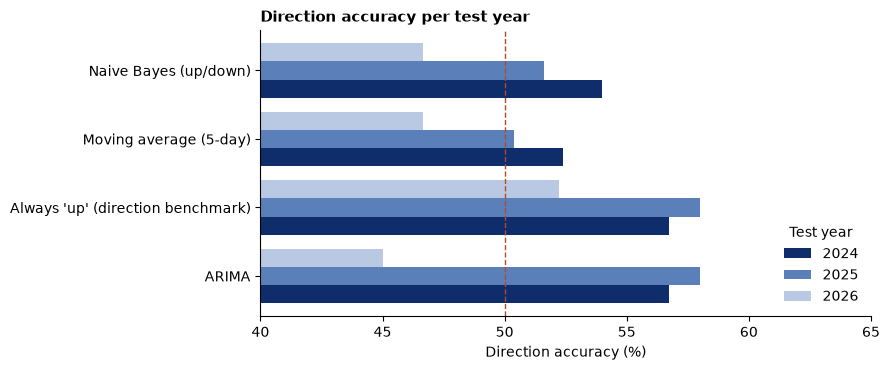

In [14]:
dir_fold = (by_fold.dropna(subset=["Direction %"])
            .pivot(index="Model", columns="test_year", values="Direction %"))
fig, ax = plt.subplots(figsize=(9, 3.8))
n = len(dir_fold.columns)
width = 0.8 / n
colors = ["#0f2d6b", "#5b7fb8", "#b9c9e3"]
for j, yr in enumerate(dir_fold.columns):
    ax.barh(np.arange(len(dir_fold)) + (j - (n - 1) / 2) * width, dir_fold[yr],
            height=width, color=colors[j % len(colors)], label=str(yr))
ax.axvline(50, color="#b24a28", ls="--", lw=1)
ax.set_yticks(range(len(dir_fold)), dir_fold.index)
ax.set_xlim(40, max(65, np.nanmax(dir_fold.values) + 3))
ax.set_xlabel("Direction accuracy (%)")
ax.set_title("Direction accuracy per test year", fontsize=11, fontweight="bold", loc="left")
ax.legend(frameon=False, title="Test year", loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{OUT}/fig_direction_by_fold.png", dpi=200, bbox_inches="tight")
plt.show()

### RMSE by test year (error-based models)
Lower is better. Bars close to the naive bar mean the model adds little over predicting zero.

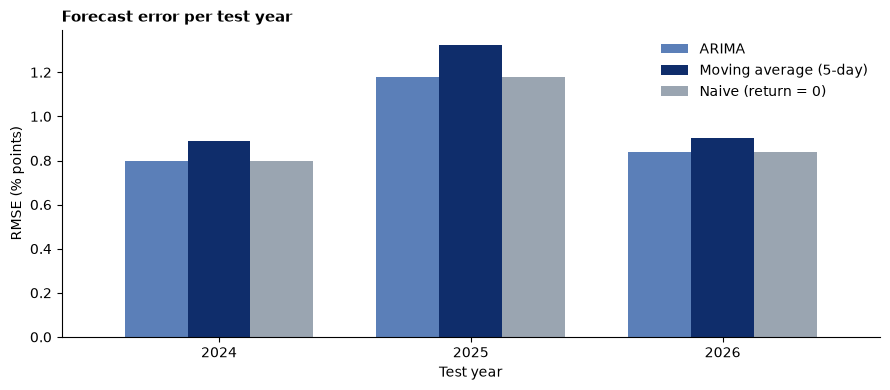

In [15]:
rmse_fold = (by_fold.dropna(subset=["RMSE"])
             .pivot(index="test_year", columns="Model", values="RMSE") * 100)
ax = rmse_fold.plot(kind="bar", figsize=(9, 4), color=["#5b7fb8", "#0f2d6b", "#9aa5b1"],
                    rot=0, width=0.75)
ax.set_ylabel("RMSE (% points)")
ax.set_xlabel("Test year")
ax.set_title("Forecast error per test year", fontsize=11, fontweight="bold", loc="left")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT}/fig_rmse_by_fold.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Files written

In [16]:
sorted(os.listdir(OUT))

['arima_orders.csv',
 'fig6_arima_vs_actual_2025.png',
 'fig_direction_accuracy.png',
 'fig_direction_by_fold.png',
 'fig_level_vs_return.png',
 'fig_rmse_by_fold.png',
 'stationarity.csv',
 'table6_by_fold.csv',
 'table6_results.csv']

## 10. Check against the midterm
The shared harness must reproduce the midterm RMSE (0.966 / 1.073 / 0.964). `python src/smoke_test.py` runs the same check.

In [17]:
midterm = {"Naive (return = 0)": 0.966, "Moving average (5-day)": 1.073, "ARIMA": 0.964}
t = table6.set_index("Model")
for name, r in midterm.items():
    print(f"{name:24s} RMSE {t.loc[name, 'RMSE (%)']:.3f}  midterm {r}  {'OK' if abs(t.loc[name, 'RMSE (%)'] - r) <= 0.01 else 'DIFFERENT'}")
print(f"Test days pooled: {len(P)}; 'always up' direction = {t.loc['Always \'up\' (direction benchmark)', 'Direction %']:.1f}%")

Naive (return = 0)       RMSE 0.966  midterm 0.966  OK
Moving average (5-day)   RMSE 1.073  midterm 1.073  OK
ARIMA                    RMSE 0.964  midterm 0.964  OK
Test days pooled: 682; 'always up' direction = 56.0%
